# <h3 align="center">__Module 2 Activity__</h3>
# <h3 align="center">__Assigned at the start of Module 2__</h3>
# <h3 align="center">__Due at the end of Module 2__</h3><br>



# Weekly Discussion Forum Participation

Each week, you are required to participate in the module’s discussion forum. The discussion forum consists of the week's Module Activity, which is released at the beginning of the module. You must complete/attempt the activity before you can post about the activity and anything that relates to the topic. 

## Grading of the Discussion

### 1. Initial Post:
Create your thread by **Day 5 (Saturday night at midnight, PST).**

### 2. Responses:
Respond to at least two other posts by **Day 7 (Monday night at midnight, PST).**

---

## Grading Criteria:

Your participation will be graded as follows:

### Full Credit (100 points):
- Submit your initial post by **Day 5.**
- Respond to at least two other posts by **Day 7.**

### Half Credit (50 points):
- If your initial post is late but you respond to two other posts.
- If your initial post is on time but you fail to respond to at least two other posts.

### No Credit (0 points):
- If both your initial post and responses are late.
- If you fail to submit an initial post and do not respond to any others.

---

## Additional Notes:

- **Late Initial Posts:** Late posts will automatically receive half credit if two responses are completed on time.
- **Substance Matters:** Responses must be thoughtful and constructive. Comments like “Great post!” or “I agree!” without further explanation will not earn credit.
- **Balance Participation:** Aim to engage with threads that have fewer or no responses to ensure a balanced discussion.

---

## Avoid:
- A number of posts within a very short time-frame, especially immediately prior to the posting deadline.
- Posts that complement another post, and then consist of a summary of that.


# __1. Module 2__<br>

A covariance matrix is a square matrix that captures the pairwise covariance between multiple features in a dataset. Each element $C[i,j]$ represents the covariance between the $i$-th and $j$-th features. Diagonal elements represent variances of individual features.

Why is it Important?

* Multivariate Relationships: It helps understand how features move together (positive/negative correlation).
* Dimensionality Reduction: It's the foundation of techniques like Principal Component Analysis (PCA).
* Data Representation: Useful for understanding the structure of multivariate data in fields like finance, image processing, and machine learning.

## Covariance Equation

The covariance between two variables $X_i$ and $X_j$ over $n$ observations is given by:

$$C_{i,j} = \frac{1}{n-1} \sum_{k=1}^{n} (X_{ki} - \mu_i)(X_{kj} - \mu_j)$$

where,
*  $X_{ki}$  and $ X_{kj}$ are values of variables $X_i$ and $X_j$ for the $k$-th observation.
*   $\mu_i$  and  $\mu_j$ are the means of $X_i$ and $X_j$, respectively.
*   $n$ is the total number of observations.


## Covariance Matrix Representation

For a dataset with $d$ features, the covariance matrix $C$ is represented as:

$$\begin{bmatrix}
C_{1,1} & C_{1,2} & C_{1,3} & \dots  & C_{1,d} \\
C_{2,1} & C_{2,2} & C_{2,3} & \dots  & C_{2,d} \\
C_{3,1} & C_{3,2} & C_{3,3} & \dots  & C_{3,d} \\
\vdots  & \vdots  & \vdots  & \ddots & \vdots  \\
C_{d,1} & C_{d,2} & C_{d,3} & \dots  & C_{d,d} \\
\end{bmatrix}$$

This represents a $d \times d$ symmetric matrix, where each element $C_{i,j}$ is the covariance between the variables $X_i$ and $X_j$.

### Without using any Python packages like `numpy` or `pandas`, write a function to calculate the covariance matrix for a given dataset.

In [1]:
def covariance_matrix(data):
    n = len(data)
    if n < 2:
        raise ValueError("Need at least 2 samples")
    
    cols = len(data[0])
    
    # Column means
    means = [sum(row[j] for row in data) / n for j in range(cols)]
    
    # Covariance matrix (using n-1 for unbiased estimate)
    cov = [[0.0] * cols for _ in range(cols)]
    for i in range(cols):
        for j in range(i, cols):
            val = sum((row[i] - means[i]) * (row[j] - means[j]) for row in data) / (n - 1)
            cov[i][j] = val
            cov[j][i] = val  # symmetric
    
    return cov

Use your new covariance matrix function to compute the covariance matrix of the first 5 rows of the iris dataset. 

In [2]:
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# iris is a Bunch object, similar to a dictionary, containing data and metadata
# The features (measurements) of the Iris dataset are stored in 'data'
iris_data = iris.data

# The labels (species of each instance) are stored in 'target'
iris_labels = iris.target

# The names of the features and labels are also stored
feature_names = iris.feature_names
label_names = iris.target_names

# To see the shape of the dataset
print("Data shape:", iris_data.shape)  # e.g., (150, 4)
print("Labels shape:", iris_labels.shape)  # e.g., (150,)

# If you want to see the first few entries
iris_5 = [[float(x) for x in row] for row in iris_data[:5]]
print("First 5 rows of data:\n", iris_5)
print("First 5 labels:", iris_labels[:5])

labels =  feature_names
cov = covariance_matrix(iris_5)
for label, row in zip(labels, cov):
    print(f"{label}: {[round(v,4) for v in row]}")

Data shape: (150, 4)
Labels shape: (150,)
First 5 rows of data:
 [[5.1, 3.5, 1.4, 0.2], [4.9, 3.0, 1.4, 0.2], [4.7, 3.2, 1.3, 0.2], [4.6, 3.1, 1.5, 0.2], [5.0, 3.6, 1.4, 0.2]]
First 5 labels: [0 0 0 0 0]
sepal length (cm): [0.043, 0.0365, -0.0025, 0.0]
sepal width (cm): [0.0365, 0.067, -0.0025, 0.0]
petal length (cm): [-0.0025, -0.0025, 0.005, 0.0]
petal width (cm): [0.0, 0.0, 0.0, 0.0]


### Discuss the relationship between the variables.

- Since all 5 petals had identical petal width (0.2), there is zero covariance between all of the features, so that row of the covariance matrix being zeros makes sense. 
- Sepal length and sepal width has low covariances, so there seems to be a strong correlation between the two. So flowers with longer sepals tend to have wider sepals as well (and vice versa).
- Petal length has a small negative covariance with sepal length and sepal width. Its a somewhat weak relationship (maybe neglible), but it points to the two variables potentially having an inverse relationship
- Overall, the covariance values are pretty small. It's possible that because these 5 rows all belong to the same species, this species has these variables in common.

### Plot data points for 2 of the features in the dataset and show how the covariance matrix reflects the orientation and spread of data.

- The scatter plot below shows a clear upward trend - as sepal length increases, sepal width tends to increase as well. This is reflected by the stronger (somehwat larger) covariance value of 0.0365.
- The ellipse captures both orientation and spread. It's diagonal tilt follow the direction of the trend line, which is postive. The ellipse is taller than wide betauce sepal width as a standalone features has a higher spread than sepal length.

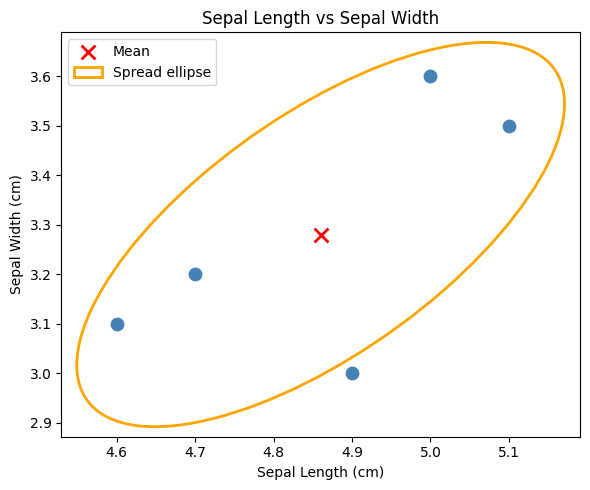

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math

x = [row[0] for row in iris_5]
y = [row[1] for row in iris_5]
mx, my = sum(x)/len(x), sum(y)/len(y)

a, b, c = cov[0][0], cov[0][1], cov[1][1]

disc = math.sqrt(((a - c) / 2) ** 2 + b ** 2)
lam1, lam2 = (a + c) / 2 + disc, (a + c) / 2 - disc
angle = math.degrees(0.5 * math.atan2(2 * b, a - c))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x, y, color='steelblue', s=80, zorder=5)
ax.scatter([mx], [my], color='red', marker='x', s=100, linewidths=2, zorder=6, label='Mean')
ax.add_patch(patches.Ellipse((mx, my), 3*math.sqrt(lam1), 3*math.sqrt(lam2),
           angle=angle, edgecolor='orange', facecolor='none', linewidth=2, label='Spread ellipse'))
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Sepal Width (cm)')
ax.set_title('Sepal Length vs Sepal Width')
ax.legend()
plt.tight_layout()
plt.show()

# References
[1] Thomas H. Cormen, Charles E. Leiserson, Ronald L. Rivest, and Clifford Stein. Introduction to
Algorithms, Third Edition. MIT Press and McGraw-Hill, 2009. ISBN-13: 978-0-262-03384-8<br><br>

[2] Stuart Russell and Peter Norvig. Artificial Intelligence: A Modern Approach, 4th Edition.
Pearson, 2020. ISBN-13: 978-0-13-461099-3
Chapter 20: Learning Probabilistic Models — covers multivariate Gaussian distributions and
covariance matrices in the context of statistical learning.<br><br>

[3] R. A. Fisher. The Use of Multiple Measurements in Taxonomic Problems. Annals of Eugenics,
7(2):179–188, 1936. — original source of the Iris dataset used in this activity<br><br>